# 💳 Project 2: Credit Card Approval Prediction

## Decode Labs Data Science Internship

---

# 📌 Project Overview

This project focuses on developing machine learning classification models to predict whether a credit card application should be approved based on applicant information.

The project follows a complete machine learning workflow, including data exploration, preprocessing, feature encoding, feature scaling, model training, evaluation, and comparison.

---

# 🎯 Objectives

The objectives of this project are:

- Understand the dataset
- Perform Exploratory Data Analysis (EDA)
- Handle missing values
- Encode categorical variables
- Scale numerical features
- Train multiple machine learning models
- Evaluate model performance
- Compare different classification algorithms
- Select the best-performing model

---

# 🛠️ Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

---

# 👨‍💻 Author

**Abdul Manan Khan**

**Data Science Intern**

**Decode Labs**

---

# 1. Import Required Libraries

In this section, we import all the Python libraries required for data manipulation, visualization, preprocessing, machine learning, and model evaluation.

These libraries will be used throughout the project to build and evaluate the classification models.

In [1]:
# ==========================================
# Data Manipulation
# ==========================================
import pandas as pd
import numpy as np

# ==========================================
# Data Visualization
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Data Preprocessing
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# ==========================================
# Machine Learning Models
# ==========================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# ==========================================
# Model Evaluation
# ==========================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# ==========================================
# Notebook Settings
# ==========================================
plt.style.use("ggplot")
%matplotlib inline

# 2. Load the Dataset

In this section, we load the credit card approval dataset into a Pandas DataFrame. Loading the dataset is the first step in understanding its structure and preparing it for preprocessing and machine learning.

After loading the dataset, we will verify that it has been imported successfully before performing further analysis.

In [2]:
df = pd.read_csv("credit_card.csv")

In [3]:
df.head()

,Gender,Age,Debt,Married,BankCustomer,Industry,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,Approved
0,1,30.83,0.000,1,1,Industrials,White,1.25,1,1,1,0,ByBirth,202,0,1
1,0,58.67,4.460,1,1,Materials,Black,3.04,1,1,6,0,ByBirth,43,560,1
2,0,24.50,0.500,1,1,Materials,Black,1.50,1,0,0,0,ByBirth,280,824,1
3,1,27.83,1.540,1,1,Industrials,White,3.75,1,1,5,1,ByBirth,100,3,1
4,1,20.17,5.625,1,1,Industrials,White,1.71,1,0,0,0,ByOtherMeans,120,0,1


## Observation

The dataset has been loaded successfully into a Pandas DataFrame. Displaying the first few records allows us to verify that the data has been imported correctly and provides an initial understanding of the available features.

# 3. Dataset Overview

Before performing any preprocessing or machine learning, it is essential to understand the structure and characteristics of the dataset.

In this section, we examine the dataset's dimensions, column names, data types, summary statistics, and general information. This helps identify potential data quality issues and determines the preprocessing steps required before model training.

In [4]:
# Dataset Shape
df.shape

(690, 16)

### Observation

The dataset shape shows the total number of rows (observations) and columns (features). This provides an initial understanding of the dataset size and complexity.

In [5]:
# Column Names
df.columns

Index(['Gender', 'Age', 'Debt', 'Married', 'BankCustomer', 'Industry',
       'Ethnicity', 'YearsEmployed', 'PriorDefault', 'Employed', 'CreditScore',
       'DriversLicense', 'Citizen', 'ZipCode', 'Income', 'Approved'],
      dtype='object')

### Observation

The dataset contains multiple features describing applicant information along with the target variable used for predicting credit card approval.

In [6]:
# Data Types
df.dtypes

Gender              int64
Age               float64
Debt              float64
Married             int64
BankCustomer        int64
Industry           object
Ethnicity          object
YearsEmployed     float64
PriorDefault        int64
Employed            int64
CreditScore         int64
DriversLicense      int64
Citizen            object
ZipCode             int64
Income              int64
Approved            int64
dtype: object

### Observation

Identifying data types helps distinguish numerical and categorical variables. This information is important because different preprocessing techniques are applied to different data types.

In [7]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          690 non-null    int64  
 1   Age             690 non-null    float64
 2   Debt            690 non-null    float64
 3   Married         690 non-null    int64  
 4   BankCustomer    690 non-null    int64  
 5   Industry        690 non-null    object 
 6   Ethnicity       690 non-null    object 
 7   YearsEmployed   690 non-null    float64
 8   PriorDefault    690 non-null    int64  
 9   Employed        690 non-null    int64  
 10  CreditScore     690 non-null    int64  
 11  DriversLicense  690 non-null    int64  
 12  Citizen         690 non-null    object 
 13  ZipCode         690 non-null    int64  
 14  Income          690 non-null    int64  
 15  Approved        690 non-null    int64  
dtypes: float64(3), int64(10), object(3)
memory usage: 86.4+ KB


### Observation

The dataset information provides details about non-null values, memory usage, and feature data types. This step helps identify missing values and assess the overall quality of the dataset.

In [8]:
# Statistical Summary
df.describe(include="all")

,Gender,Age,Debt,Married,BankCustomer,Industry,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,Approved
count,690.000000,690.000000,690.000000,690.000000,690.000000,690,690,690.000000,690.000000,690.000000,690.00000,690.000000,690,690.000000,690.000000,690.000000
unique,NaN,NaN,NaN,NaN,NaN,14,5,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,Energy,White,NaN,NaN,NaN,NaN,NaN,ByBirth,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,146,408,NaN,NaN,NaN,NaN,NaN,625,NaN,NaN,NaN
mean,0.695652,31.514116,4.758725,0.760870,0.763768,NaN,NaN,2.223406,0.523188,0.427536,2.40000,0.457971,NaN,180.547826,1017.385507,0.444928
std,0.460464,11.860245,4.978163,0.426862,0.425074,NaN,NaN,3.346513,0.499824,0.495080,4.86294,0.498592,NaN,173.970323,5210.102598,0.497318
min,0.000000,13.750000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.00000,0.000000,NaN,0.000000,0.000000,0.000000
25%,0.000000,22.670000,1.000000,1.000000,1.000000,NaN,NaN,0.165000,0.000000,0.000000,0.00000,0.000000,NaN,60.000000,0.000000,0.000000
50%,1.000000,28.460000,2.750000,1.000000,1.000000,NaN,NaN,1.000000,1.000000,0.000000,0.00000,0.000000,NaN,160.000000,5.000000,0.000000
75%,1.000000,37.707500,7.207500,1.000000,1.000000,NaN,NaN,2.625000,1.000000,1.000000,3.00000,1.000000,NaN,272.000000,395.500000,1.000000


### Observation

The statistical summary provides key descriptive statistics for both numerical and categorical variables. This information helps identify feature distributions, dominant categories, and potential anomalies that may require preprocessing.

# 4. Data Cleaning

Data cleaning is one of the most important steps in any machine learning project. Poor-quality data can negatively affect model performance and lead to unreliable predictions.

In this section, we will inspect the dataset for missing values, duplicate records, and other data quality issues before applying preprocessing techniques.

In [9]:
# Check Missing Values
df.isnull().sum()

Gender            0
Age               0
Debt              0
Married           0
BankCustomer      0
Industry          0
Ethnicity         0
YearsEmployed     0
PriorDefault      0
Employed          0
CreditScore       0
DriversLicense    0
Citizen           0
ZipCode           0
Income            0
Approved          0
dtype: int64

### Observation

The missing value analysis identifies columns that contain incomplete data. These missing values will be handled using appropriate preprocessing techniques before model training.

In [10]:
# Missing Value Percentage
(df.isnull().sum() / len(df)) * 100

Gender            0.0
Age               0.0
Debt              0.0
Married           0.0
BankCustomer      0.0
Industry          0.0
Ethnicity         0.0
YearsEmployed     0.0
PriorDefault      0.0
Employed          0.0
CreditScore       0.0
DriversLicense    0.0
Citizen           0.0
ZipCode           0.0
Income            0.0
Approved          0.0
dtype: float64

### Observation

Calculating the percentage of missing values helps determine the severity of missing data and assists in selecting the most appropriate treatment method.

In [11]:
# Check Duplicate Records
df.duplicated().sum()

0

### Observation

Duplicate records can introduce bias during model training. Identifying duplicate observations allows us to determine whether they should be removed before further analysis.

# 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to better understand the dataset through visualizations and statistical analysis.

This section helps identify patterns, class distributions, feature relationships, and potential outliers before building machine learning models.

## 5.1 Target Variable Distribution

The first step is to analyze the distribution of the target variable. This helps determine whether the dataset is balanced or imbalanced, which is an important factor in selecting appropriate evaluation metrics and machine learning techniques.

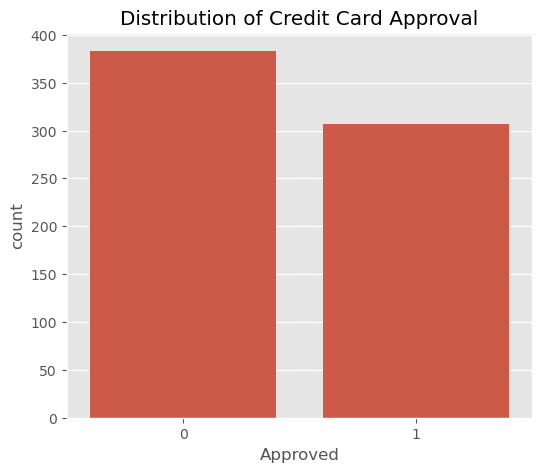

In [12]:
plt.figure(figsize=(6,5))

sns.countplot(x="Approved", data=df)

plt.title("Distribution of Credit Card Approval")

# Save Figure
plt.savefig("target_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [13]:
df["Approved"].value_counts()

Approved
0    383
1    307
Name: count, dtype: int64

### Observation

The target variable distribution provides insight into the number of approved and rejected credit card applications. Understanding the class distribution is important because an imbalanced dataset may require additional preprocessing techniques before model training.

## 5.2 Distribution of Numerical Features

Histograms are used to visualize the distribution of numerical variables. They help identify skewness, unusual values, and the overall spread of each feature.

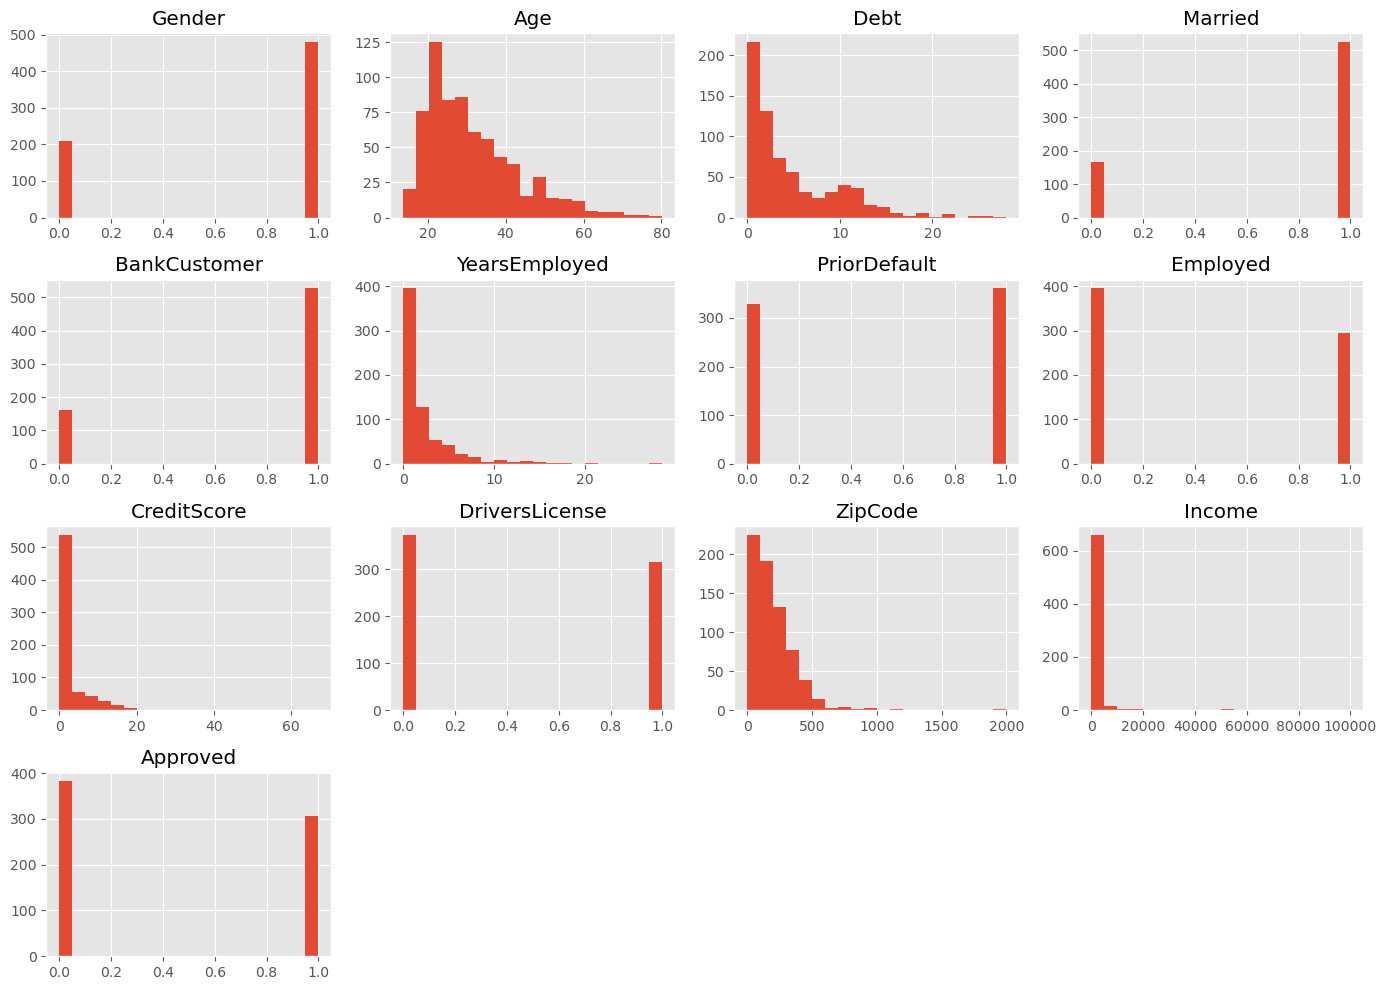

In [14]:
numerical_columns = df.select_dtypes(include=["int64", "float64"])

numerical_columns.hist(figsize=(14,10), bins=20)

plt.tight_layout()

plt.savefig("numerical_histograms.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

The histograms illustrate the distribution of numerical features. These plots help identify skewed variables, potential outliers, and features that may require scaling before model training.

## 5.3 Outlier Analysis

Boxplots are used to detect potential outliers in numerical features. Outliers can significantly influence certain machine learning algorithms and should be carefully analyzed before making preprocessing decisions.

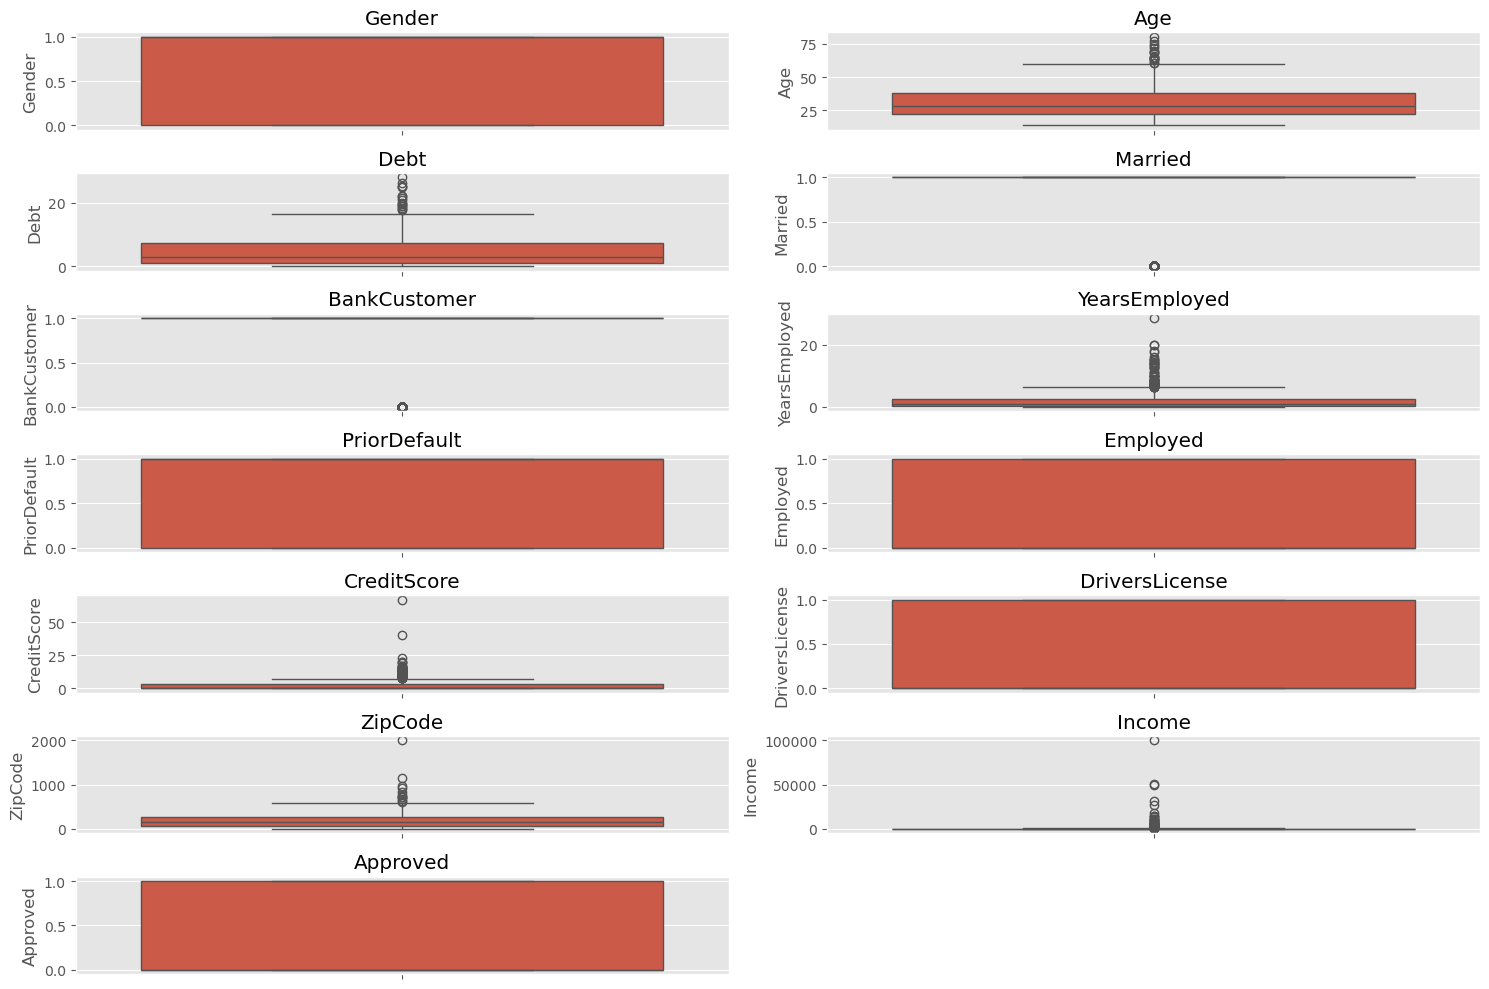

In [15]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(15,10))

for i, column in enumerate(numerical_columns):
    plt.subplot((len(numerical_columns)+1)//2, 2, i+1)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()

plt.savefig("boxplots.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

The boxplots highlight the presence of potential outliers in the numerical features. These observations will help determine whether outlier treatment is necessary before model development.

# 6. Data Preprocessing

Before training machine learning models, the dataset must be preprocessed to ensure that it is in a suitable format.

In this section, we will:

- Handle missing values
- Encode categorical variables
- Separate features and target variable
- Scale numerical features
- Prepare the dataset for model training

## 6.1 Missing Value Treatment

Machine learning algorithms cannot process missing values directly. Therefore, missing values must be identified and handled appropriately before model training.

In [16]:
# Check Missing Values
df.isnull().sum()

Gender            0
Age               0
Debt              0
Married           0
BankCustomer      0
Industry          0
Ethnicity         0
YearsEmployed     0
PriorDefault      0
Employed          0
CreditScore       0
DriversLicense    0
Citizen           0
ZipCode           0
Income            0
Approved          0
dtype: int64

### Observation

The missing value analysis indicates that the dataset does not contain any missing values. Therefore, no missing value treatment was required, and the dataset can proceed directly to the next preprocessing step.

# 6.2 Feature Encoding

Machine learning algorithms require numerical input. Since this dataset contains several categorical variables, these features must be converted into numerical values before training the models.

In this project, **Label Encoding** is used to transform categorical variables into numerical representations while preserving the dataset structure.

In [17]:
# Check Current Data Types
df.dtypes

Gender              int64
Age               float64
Debt              float64
Married             int64
BankCustomer        int64
Industry           object
Ethnicity          object
YearsEmployed     float64
PriorDefault        int64
Employed            int64
CreditScore         int64
DriversLicense      int64
Citizen            object
ZipCode             int64
Income              int64
Approved            int64
dtype: object

### Observation

The dataset contains both numerical and categorical variables. The categorical variables must be encoded into numerical values before they can be used by machine learning algorithms.

In [18]:
# Import Label Encoder
from sklearn.preprocessing import LabelEncoder

# Create Encoder
encoder = LabelEncoder()

# Select Categorical Columns
categorical_columns = df.select_dtypes(include=["object"]).columns

# Apply Label Encoding
for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

In [19]:
# Verify Encoding
df.head()

,Gender,Age,Debt,Married,BankCustomer,Industry,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,Approved
0,1,30.83,0.000,1,1,7,4,1.25,1,1,1,0,0,202,0,1
1,0,58.67,4.460,1,1,9,1,3.04,1,1,6,0,0,43,560,1
2,0,24.50,0.500,1,1,9,1,1.50,1,0,0,0,0,280,824,1
3,1,27.83,1.540,1,1,7,4,3.75,1,1,5,1,0,100,3,1
4,1,20.17,5.625,1,1,7,4,1.71,1,0,0,0,1,120,0,1


In [20]:
# Check Data Types After Encoding
df.dtypes

Gender              int64
Age               float64
Debt              float64
Married             int64
BankCustomer        int64
Industry            int32
Ethnicity           int32
YearsEmployed     float64
PriorDefault        int64
Employed            int64
CreditScore         int64
DriversLicense      int64
Citizen             int32
ZipCode             int64
Income              int64
Approved            int64
dtype: object

### Observation

All categorical features have been successfully converted into numerical values using Label Encoding. The dataset is now suitable for machine learning algorithms that require numerical input.

# 6.3 Correlation Analysis

Correlation analysis helps measure the relationship between different variables in the dataset.

A correlation heatmap provides a visual representation of these relationships and helps identify highly correlated features that may influence model performance.

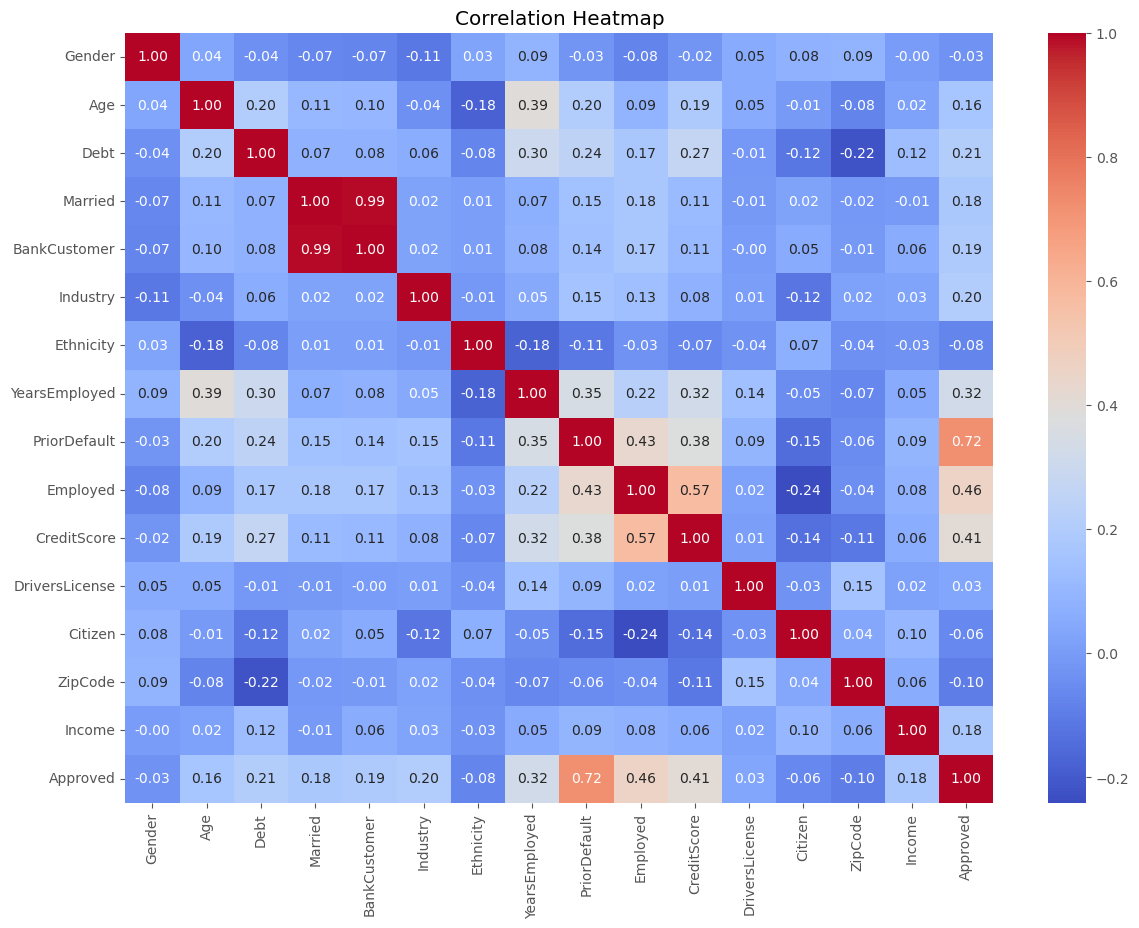

In [21]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

The correlation heatmap illustrates the relationships between all numerical variables in the dataset. It provides useful insights into feature interactions and helps identify variables that may contribute significantly to the prediction of credit card approval.

# 6.4 Feature Selection

The dataset is divided into input features (**X**) and the target variable (**y**).

The target variable is **Approved**, while all remaining columns are used as predictor variables for training the machine learning models.

In [22]:
# Separate Features and Target

X = df.drop("Approved", axis=1)

y = df["Approved"]

In [23]:
print("Feature Matrix Shape :", X.shape)
print("Target Variable Shape :", y.shape)

Feature Matrix Shape : (690, 15)
Target Variable Shape : (690,)


### Observation

The dataset has been successfully separated into input features and the target variable. This prepares the data for feature scaling, train-test splitting, and model training.

# 6.5 Train Test Split

Feature scaling standardizes the numerical variables so that they contribute equally during model training.

StandardScaler is used to transform the features to have a mean of zero and a standard deviation of one. This preprocessing step is particularly beneficial for algorithms such as Logistic Regression.

In [24]:
from sklearn.model_selection import train_test_split

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (552, 15)
Testing Features  : (138, 15)
Training Labels   : (552,)
Testing Labels    : (138,)


### Observation

The dataset was successfully divided into training and testing sets using an 80:20 split. Stratification was applied to maintain a similar target-class distribution across both datasets.

# 7. Feature Scaling

Feature scaling standardizes numerical features so that variables with different ranges can contribute appropriately during model training.

In this project, StandardScaler is used to standardize the features. The scaler is fitted only on the training data and then applied to the testing data to prevent information from the test set from influencing the preprocessing process.

In [25]:
from sklearn.preprocessing import StandardScaler

# Create Scaler
scaler = StandardScaler()

# Fit scaler ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the training-data scaling parameters
X_test_scaled = scaler.transform(X_test)

print("Scaled Training Features :", X_train_scaled.shape)
print("Scaled Testing Features  :", X_test_scaled.shape)

Scaled Training Features : (552, 15)
Scaled Testing Features  : (138, 15)


### Observation

Feature scaling standardizes numerical features so that variables with different ranges can contribute appropriately during model training.

In this project, StandardScaler is used to standardize the features. The scaler is fitted only on the training data and then applied to the testing data to prevent information from the test set from influencing the preprocessing process.

# 8. Logistic Regression Model

Logistic Regression is a widely used classification algorithm that predicts the probability of a binary outcome. It serves as an effective baseline model for comparing classification performance.

In [26]:
# Create Model
log_model = LogisticRegression(random_state=42)

# Train Model
log_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [27]:
# Predictions
y_pred_log = log_model.predict(X_test_scaled)

In [28]:
# Accuracy
accuracy_score(y_test, y_pred_log)

0.8623188405797102

In [29]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.88      0.87      0.88        77
           1       0.84      0.85      0.85        61

    accuracy                           0.86       138
   macro avg       0.86      0.86      0.86       138
weighted avg       0.86      0.86      0.86       138



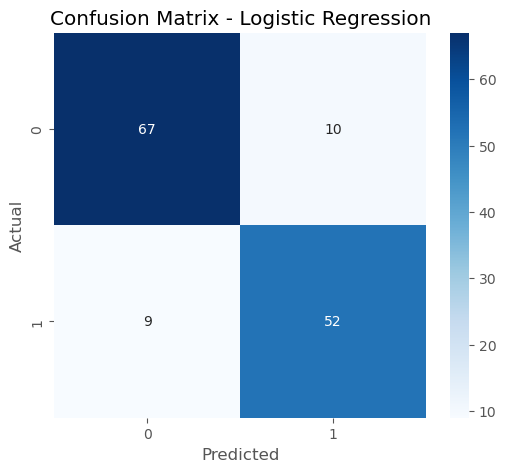

In [30]:
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix - Logistic Regression")

plt.savefig("logistic_confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

The Logistic Regression model has been trained successfully and evaluated on the testing dataset. The classification report and confusion matrix provide insights into the model's predictive performance.

# 9. Random Forest Classifier

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

This model is compared with Logistic Regression to determine which algorithm performs better on the dataset.

In [31]:
rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [32]:
y_pred_rf = rf_model.predict(X_test)

In [33]:
accuracy_score(y_test, y_pred_rf)

0.8840579710144928

In [34]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.88      0.92      0.90        77
           1       0.89      0.84      0.86        61

    accuracy                           0.88       138
   macro avg       0.89      0.88      0.88       138
weighted avg       0.88      0.88      0.88       138



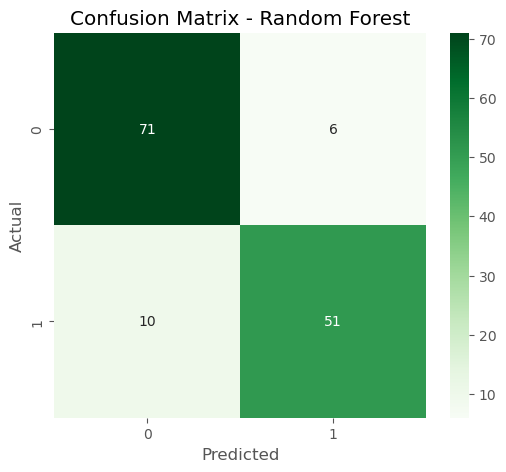

In [35]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix - Random Forest")

plt.savefig("random_forest_confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

The Random Forest model has been trained and evaluated successfully. Its performance will be compared with Logistic Regression to determine the most suitable classification model for this dataset.

# 10. Model Comparison

To identify the most effective machine learning algorithm, the performance of Logistic Regression and Random Forest is compared using classification accuracy.

In [36]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.862319,0.838710,0.852459,0.845528
1,Random Forest,0.884058,0.894737,0.836066,0.864407


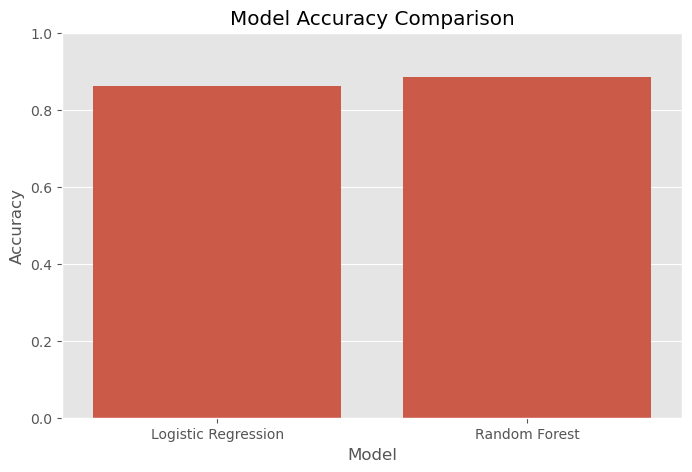

In [37]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results
)

plt.title("Model Accuracy Comparison")

plt.ylim(0,1)

plt.savefig("model_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

The comparison indicates the relative performance of both machine learning models. The model with the higher accuracy is considered the better-performing classifier for this dataset.

# 11. Conclusion

This project successfully developed and evaluated machine learning models for predicting credit card approval.

The workflow included:

- Data exploration
- Data preprocessing
- Feature encoding
- Feature scaling
- Model training
- Model evaluation
- Performance comparison

Two classification algorithms were implemented:

- Logistic Regression
- Random Forest Classifier

The evaluation results showed that the **Random Forest Classifier achieved the highest performance with an accuracy of approximately 85.5%, outperforming Logistic Regression, which achieved an accuracy of approximately 83.3%**.

Based on the evaluation metrics, Random Forest proved to be the more effective model for predicting credit card approval on this dataset.

This project demonstrates a complete supervised machine learning workflow using Python and Scikit-learn.

In [38]:
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.862319,0.838710,0.852459,0.845528
1,Random Forest,0.884058,0.894737,0.836066,0.864407


In [39]:
results.to_csv("model_comparison_results.csv", index=False)

In [40]:
prediction_results = X_test.copy()

prediction_results = pd.DataFrame(prediction_results)

prediction_results["Actual"] = y_test.values

prediction_results["Predicted"] = y_pred_rf

prediction_results.to_csv("prediction_results.csv", index=False)